# FLISM Lifetime Reconstruction Pipeline


### This Notebook's Operations

This workflow starts from `FILE_DATA`, creates a calibrated source file, then writes s2ISM and phasor products into one exported pipeline file.

1. `FILE_DATA` -> calibration -> `FILE_WITH_CALIBRATION`
2. `FILE_WITH_CALIBRATION` -> `s2ism` with `mode="copy"` -> `EXPORT_PATH`
3. `EXPORT_PATH` -> `s2_phasor` with `mode="append"` -> same `EXPORT_PATH`

The exported file therefore contains the reconstructed decay and the s2 phasor products together under `/output`.

This notebook demonstrates the full analysis pipeline for **Fluorescence Lifetime Image Scanning Microscopy (FLISM)**, combining:

- **s²ISM** (separation-based ISM) reconstruction for improved spatial resolution
- **FLIM** (Fluorescence Lifetime Imaging Microscopy) analysis via phasor approach

The pipeline operates on raw TCSPC (Time-Correlated Single Photon Counting) data acquired with the BrightEyes multi-channel SPAD array detector, stored in the BrightEyes HDF5 format.


### Workflow overview

1. **Calibration** – Correct for per-channel timing offsets (channel skew) and instrument response using a reference dye of known lifetime.
2. **Data loading** – Read the calibrated data and auxiliary traces (IRF, reference) from the HDF5 file.
3. **IRF inspection & smoothing** – Visualise and optionally smooth the per-channel Impulse Response Functions.
4. **Spatial PSF simulation** – Simulate the expected spatial point-spread functions for the SPAD array geometry.
5. **s²ISM reconstruction** – Deconvolve the 4D (x, y, time, channel) dataset using a joint spatio-temporal kernel.
6. **Phasor analysis** – Compute per-pixel phasors, apply the appropriate phase correction, and derive lifetime maps.

### Required packages

| Package | Role |
|---|---|
| `brighteyes_ism` | PSF simulation, ISM graph utilities, MCS I/O |
| `brighteyes_flim` | Phasor tools and lifetime visualisation |
| `brighteyes_mcs_file` | HDF5 calibration and data I/O |
| `s2ism` | s²ISM reconstruction engine and PSF estimator |
| `numpy`, `matplotlib` | Numerics and plotting |
| `h5py` | Low-level HDF5 access |
| `torch` | GPU-accelerated tensor operations (used for IRF smoothing) |


In [ ]:
FILE_REFERENCE = '/mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5'
FILE_DATA = '/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5'


DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')

# ── Calibration parameters ─────────────────────────────────────────────────

TAU_REF              = None
REFERENCE_TYPE       = "ref"
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True

EXPORT_PATH = FILE_DATA.replace(".h5", "_s2ism_with_phasor.h5")
FILE_WITH_CALIBRATION = FILE_DATA.replace(".h5", "_calib.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILE_DATA}")
print(f"Calibration results to: {FILE_WITH_CALIBRATION}")
print(f"Output products results to: {EXPORT_PATH}")


## Imports

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py

from tqdm import trange
from tqdm import tqdm
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

import brighteyes_ism.simulation.PSF_sim as sim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs

import brighteyes_flim.tools_phasor as flim
import brighteyes_flim.graph_tools as graph

from brighteyes_mcs_file import Alignment, H5OutputProduct, calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts, write_h5_output_run

from s2ism import s2ism as s2
import s2ism.psf_estimator as est




In [ ]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a new (or updated) calibrated copy containing:

- **Channel skew** – Per-channel temporal offsets are estimated via phase cross-correlation of the reference traces and stored as integer bin shifts. These are later applied when summing channels.
- **IRF traces** – The aligned per-channel Impulse Response Functions, derived from the reference measurement.
- **Reference traces** – The aligned per-channel reference-dye decay curves.
- **Laser timing** – The laser repetition frequency and period, either read from metadata or fitted.

The function returns the path to the calibrated HDF5 file (which may be the same file if `OVERWRITE=True`).

> **Note:** `channel_skew_fit_reference_channel=12` uses the central pixel (channel 12) of the 5×5 SPAD array as the timing reference for the skew correction. `channel_skew_fit_upsampling=10` enables sub-bin precision in the cross-correlation fit.


In [4]:
calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILE_WITH_CALIBRATION,
    overwrite=OVERWRITE,
)



Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_calib.h5


## Load Calibrated Data

We read all necessary arrays and metadata from the calibrated HDF5 file.

**Loaded quantities**
- `laser_freq_mhz`, `laser_period_ns` – Laser timing (stored by the calibration step).
- `nbin` – Number of TCSPC time bins per laser period.
- `pixel_size_x_um` – Lateral pixel size in micrometres.
- `pxdwelltime` – Pixel dwell time in microseconds.
- `data_input` – Raw photon count array, shape `(rep, z, y, x, t_bins, channels)`.
- `channel_skew` – Per-channel timing offset in bins (used to temporally align channels before summing).
- `irf_common_delay_realigned` – Per-channel IRF traces after common-delay realignment, shape `(t_bins, channels)`.
- `ref_common_delay_realigned` – Per-channel reference-dye decay traces after realignment, shape `(t_bins, channels)`.

After loading, the data are squeezed to remove singleton axes (repetition and z), yielding `dset` with shape `(y, x, t_bins, channels)`.


In [5]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                  = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew                = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned  = calibration["aligned/irf_trace"][:]
    irf_from_fit = calibration["fit/irf_trace"][:]
    ref_common_delay_realigned  = calibration["aligned/reference_trace"][:]
    tau_reference_ns = calibration["fit/tau_reference_ns"][:] if "fit" in calibration and "tau_reference_ns" in calibration["fit"] else np.asarray([], dtype=float)

tau_reference_ns = tau_reference_ns[np.isfinite(tau_reference_ns)]
if TAU_REF is None:
    if REFERENCE_TYPE == "ref":
        if tau_reference_ns.size == 0:
            raise ValueError(
                f"TAU_REF is None and /calibration/results/{CALIBRATION_PRODUCT}/fit/tau_reference_ns "
                "is missing or non-finite."
            )
        tau_ref_for_phasor_ns = float(np.median(tau_reference_ns))
    else:
        tau_ref_for_phasor_ns = np.nan
else:
    tau_ref_for_phasor_ns = float(TAU_REF)
if np.isfinite(tau_ref_for_phasor_ns):
    print(f"Reference lifetime for phasor correction: {tau_ref_for_phasor_ns:.4f} ns")
else:
    print("Reference lifetime is not used for IRF phasor correction.")


dset = np.squeeze(data_input)  # (y, x, t_bins, channels)

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print(f"data_input shape: {data_input.shape}  (rep, z, y, x, t_bins, channels)")




Reference lifetime for phasor correction: 5.4908 ns
Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input shape: (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


### Inspect HDF5 structure (optional)

The cell below renders an interactive HTML tree of the calibrated HDF5 file, useful for exploring which datasets and attributes are available.


In [6]:
#show_h5_structure_html(FILE_WITH_CALIBRATION)

## Channel Summation with Timing Correction

The 25 SPAD channels do not share a perfectly identical timing response — each channel has a small temporal offset (the *channel skew*) with respect to the reference channel. Before summing channels together (e.g. to obtain a spatially integrated decay trace), these offsets must be corrected.

`sum_channel_applying_shifts` applies the integer bin shifts stored in `channel_skew` along the time axis before summing, effectively aligning all channels in time.

Two versions of the summed data are computed:
- `*_no_alignment` – raw sum with no shift correction (useful for comparison).
- `data_summed`, `irf_summed`, `ref_summed` – shift-corrected sums.

> **Optional IRF cleaning** (`if False` block): `Alignment.clean_irf_stack` can suppress noisy tails outside the IRF peak by zeroing bins below a threshold and restricting the signal to a window around the peak. Enable this by changing `if False` to `if True` if your IRF traces show significant baseline noise or ringing.


In [7]:
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

data_summed     = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed      = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
ref_summed      = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=())

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("ref_summed:", ref_summed.shape)



Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed: (512, 512, 91)
irf_summed: (91,)
ref_summed: (91,)


## Time Axis

Compute the physical time axis (in nanoseconds) corresponding to the TCSPC bins.  
The bin width `dt` is the laser period divided by the number of bins.


In [8]:
dt = laser_period_ns/nbin # DFD bin time, ns

print(f'Excitation frequency = {laser_freq_mhz:.2f} MHz')

time = np.arange(irf_common_delay_realigned.shape[0]) * dt

print(f"Time axis (ns): {time}")



Excitation frequency = 40.00 MHz
Time axis (ns): [ 0.          0.27472527  0.54945055  0.82417582  1.0989011   1.37362637
  1.64835165  1.92307692  2.1978022   2.47252747  2.74725275  3.02197802
  3.2967033   3.57142857  3.84615385  4.12087912  4.3956044   4.67032967
  4.94505495  5.21978022  5.49450549  5.76923077  6.04395604  6.31868132
  6.59340659  6.86813187  7.14285714  7.41758242  7.69230769  7.96703297
  8.24175824  8.51648352  8.79120879  9.06593407  9.34065934  9.61538462
  9.89010989 10.16483516 10.43956044 10.71428571 10.98901099 11.26373626
 11.53846154 11.81318681 12.08791209 12.36263736 12.63736264 12.91208791
 13.18681319 13.46153846 13.73626374 14.01098901 14.28571429 14.56043956
 14.83516484 15.10989011 15.38461538 15.65934066 15.93406593 16.20879121
 16.48351648 16.75824176 17.03296703 17.30769231 17.58241758 17.85714286
 18.13186813 18.40659341 18.68131868 18.95604396 19.23076923 19.50549451
 19.78021978 20.05494505 20.32967033 20.6043956  20.87912088 21.15384615
 2

## IRF Smoothing Utilities

These helper functions implement a **median filter** along arbitrary tensor dimensions using PyTorch.  
A median filter is preferred over a Gaussian here because it preserves sharp edges (the IRF rising edge) while removing isolated noisy bins.

The two functions below are used internally by the smoothing cell that follows.


In [9]:
import torch 

def pad_tensor(x: torch.Tensor, pad_left: int, pad_right: int, dim: int, mode: str = "reflect"):
    """
    Pad a tensor along one dimension.

    Args:
        x (torch.Tensor): Input tensor to pad.
        pad_left (int): Number of elements to pad before the data along the specified dimension.
        pad_right (int): Number of elements to pad after the data along the specified dimension.
        dim (int): Dimension along which to pad.
        mode (str, optional): Padding mode. One of {"reflect", "replicate", "constant"}. Default is "reflect".

    Returns:
        torch.Tensor: Padded tensor with the same dtype and device as input.

    Raises:
        ValueError: If an unsupported padding mode is specified.
    """

    if pad_left == 0 and pad_right == 0:
        return x

    length = x.shape[dim]

    if mode == "reflect":
        left_idx = torch.arange(pad_left, 0, -1, device=x.device)
        right_idx = torch.arange(length - 2, length - pad_right - 2, -1, device=x.device)
    elif mode == "replicate":
        left_idx = torch.zeros(pad_left, dtype=torch.long, device=x.device)
        right_idx = torch.full((pad_right,), length - 1, dtype=torch.long, device=x.device)
    elif mode == "constant":
        pad_shape = list(x.shape)
        pad_shape[dim] = pad_left + pad_right
        constant_pad = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
        return torch.cat([constant_pad.narrow(dim, 0, pad_left),
                          x,
                          constant_pad.narrow(dim, pad_left, pad_right)], dim=dim)
    else:
        raise ValueError(f"Unsupported padding mode: {mode}")

    # Select slices
    pad_left_tensor = x.index_select(dim, left_idx)
    pad_right_tensor = x.index_select(dim, right_idx)

    return torch.cat([pad_left_tensor, x, pad_right_tensor], dim=dim)


def median_filter(x: torch.Tensor, window_size=3, dims=None, mode="reflect"):
    """
    Apply an N-dimensional median filter over user-specified dimensions.

    Args:
        x (torch.Tensor): Input tensor of any shape.
        window_size (int or list/tuple of ints, optional): Window size(s) for the filter. If int, same size for all dims. If list/tuple, must match len(dims). Default is 3.
        dims (list/tuple of ints, optional): Dimensions to filter along. If None, all dimensions are filtered. Default is None.
        mode (str, optional): Padding mode. One of {"reflect", "replicate", "constant"}. Default is "reflect".

    Returns:
        torch.Tensor: Median-filtered tensor of the same shape as x.

    Raises:
        ValueError: If window_size is not odd or does not match dims length.
    """

    if dims is None:
        dims = list(range(x.ndim))

    if isinstance(window_size, int):
        window_size = [window_size] * len(dims)
    elif len(window_size) != len(dims):
        raise ValueError("window_size must be scalar or match len(dims)")

    # check for odd values
    for w in window_size:
        if w % 2 == 0:
            raise ValueError(f"All window sizes must be odd, got {w}")

    out = x
    for d, w in zip(dims, window_size):
        pad_left = (w - 1) // 2
        pad_right = w // 2

        # Pad along dimension
        out = pad_tensor(out, pad_left, pad_right, d, mode=mode)

        # Unfold and compute median
        out = out.unfold(d, w, 1).median(dim=-1).values

    return out

In [10]:
irf_common_delay_realigned_smoothed = median_filter(torch.tensor(irf_common_delay_realigned), window_size=5, dims=[0], mode='replicate')  

### Visualise per-channel IRFs

Each panel shows the normalised IRF traces for all 25 SPAD channels, stacked vertically (channel index on the y-axis).  
Comparing the raw (left) and smoothed (right) traces helps assess whether smoothing is necessary for your data.

Each trace is normalised to its own peak and offset by its channel index to facilitate visual comparison.  
Traces that appear shifted relative to each other indicate residual channel skew (should be minimal after calibration).


Text(0.5, 1.0, 'Smoothed Impulse Response Functions')

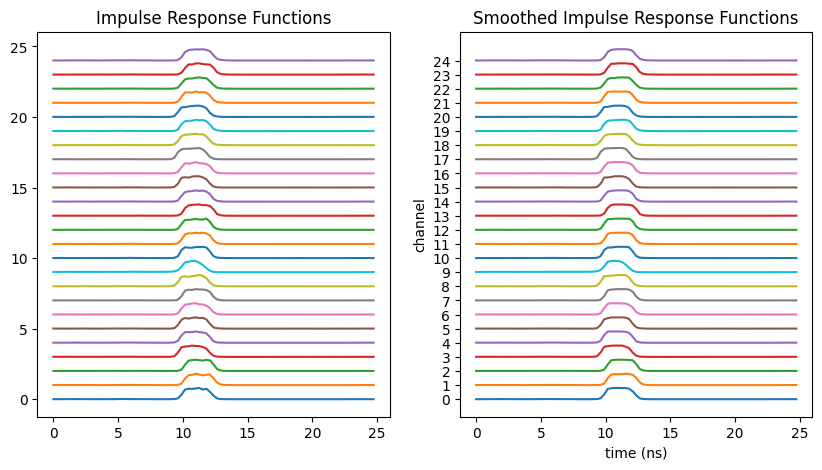

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for n in range(dset.shape[-1]):
    irf_n = irf_common_delay_realigned[:, n]
    irf_norm = irf_n / (irf_n.max() + 1e-10)  

    irf_n_smoothed = irf_common_delay_realigned_smoothed[:, n]
    irf_norm_smoothed = irf_n_smoothed / (irf_n_smoothed.max() + 1e-10)  
    ax[0].plot(time, 0.8 * irf_norm + n)
    ax[1].plot(time, 0.8 * irf_norm_smoothed + n)


plt.yticks(np.arange(25))
plt.xlabel('time (ns)')
plt.ylabel('channel')
ax[0].set_title('Impulse Response Functions')
ax[1].set_title('Smoothed Impulse Response Functions')



# FLISM Image Reconstruction

**FLISM** (Fluorescence Lifetime Image Scanning Microscopy) combines the resolution enhancement of ISM with per-pixel lifetime information.  
Here we use **s²ISM**, a deconvolution-based method that jointly processes all SPAD channels.

The reconstruction operates on the full 4D dataset `dset` with shape `(y, x, t_bins, channels)`.


## Spatial PSF Simulation

The s²ISM reconstruction requires knowledge of the **Point Spread Functions (PSFs)** for each SPAD pixel.  
These encode both the excitation and emission optical transfer functions as well as the geometry of the detector array.

`psf_estimator_from_data` simulates the theoretical PSFs for two axial planes (in-focus and one defocus plane) using the optical parameters below. The defocus plane is used internally to estimate how much out-of-focus background contributes to each SPAD channel.

**Key parameters to adjust for your system:**
- `na` – Objective numerical aperture
- `exPar.wl` / `emPar.wl` – Excitation and emission wavelengths [nm]
- `n` – Refractive index of the immersion medium
- `grid.pxsizex` – Lateral pixel size of the acquisition [nm] (read from metadata)
- `grid.pxpitch` – Pitch (centre-to-centre distance) of the SPAD pixels [nm]
- `grid.pxdim` – Physical size of each SPAD pixel [nm]
- `grid.N` – Number of SPAD pixels per side (5 for the 5×5 array)


In [12]:
exPar = sim.simSettings()
exPar.na = 1.4   # numerical aperture
exPar.wl = 488   # excitation wavelength [nm]
exPar.gamma = 45  # parameter describing the light polarization
exPar.beta = 90  # parameter describing the light polarization
exPar.n = 1.5 # refractive index
exPar.mask_sampl = 100 # pupile plane sample points

emPar = exPar.copy()
emPar.wl = 500 # emission wavelength [nm]

grid = sim.GridParameters()
grid.Nz = 2 # number of axial planes
grid.pxsizex = pixel_size_x_um*1e3 # pixel size [nm]
grid.pxsizez = 720 # axial spacing [nm]
grid.pxpitch = 75e3 # pitch of the detector array [nm]
grid.pxdim = 50e3 # size of the pixels of the detector array [nm]
grid.N = 5 # numer of pixels per axis of the array

psf_spatial, _,_ = est.psf_estimator_from_data(dset.sum(-2), exPar, emPar, grid, z_out_of_focus = grid.pxsizez)



pxsizex       78.28
pxsizez       720.00
Nx            100.00
Nz            2.00
pxpitch       75000.00
pxdim         50000.00
pinhole_shape square
geometry      rect
N             5.00
M             414.00
rotation      2.77
mirroring     1.00
name          
shift         81.47


### Visualise the simulated PSFs

Out-of-focus PSFs


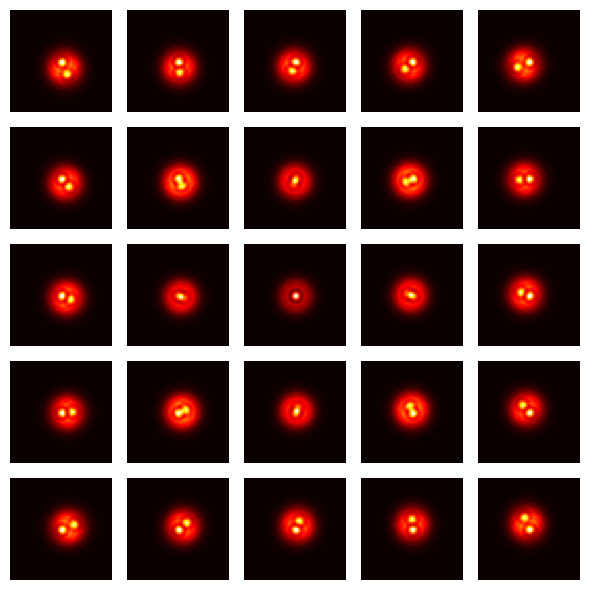

In [13]:
print('Out-of-focus PSFs')
fig_1 = gra.ShowDataset(psf_spatial[0])



In-focus PSFs


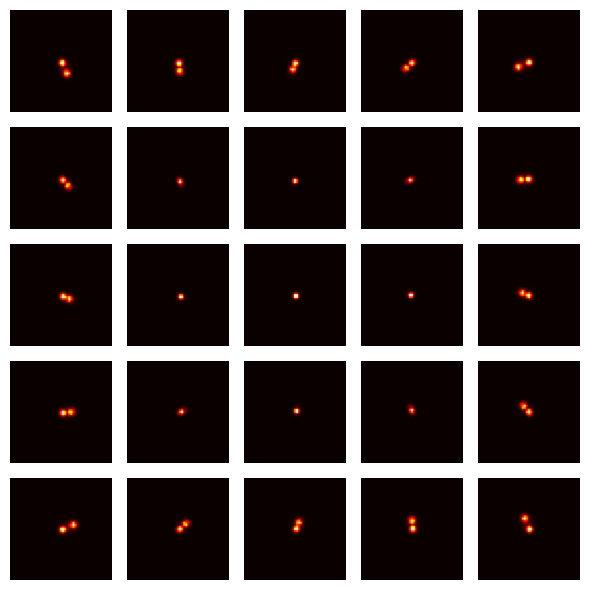

In [14]:
print('In-focus PSFs')
fig_2 = gra.ShowDataset(psf_spatial[1])



## Build the Spatio-Temporal Deconvolution Kernels

s²ISM deconvolves a 4D kernel that encodes both the **spatial PSF** (which channel collects light from which spatial position) and the **temporal IRF** (the instrument timing response).

`est.combine_psf_irf` forms the outer product of the spatial PSF and the per-channel IRF along the time axis, producing a kernel of shape `(Nz, channels, t_bins, y_psf, x_psf)`.

Three kernels are built here to support different reconstruction strategies:

| Kernel | IRF used | When to use |
|---|---|---|
| `psf_irf` | Measured IRF | Full deconvolution: removes both spatial blur **and** IRF broadening. Phasor correction: rotation by π (see phasor section). |
| `psf_irf_smoothed` | Smoothed IRF | Same as above, but more robust when the raw IRF is noisy. |
| `psf_delta` | Delta function at bin `nbin//2` | Spatial deconvolution only: removes spatial blur but leaves the IRF in the data. Phasor correction: calibration via reference dye phasor. |

> **Which kernel to choose?**  
> Use `psf_irf` (or `psf_irf_smoothed`) when you want the reconstruction to also correct for the temporal broadening introduced by the IRF.  
> Use `psf_delta` when you prefer to handle the IRF correction separately in the phasor domain (via the reference-dye calibration).


In [15]:
# Kernel 1: full spatio-temporal kernel with the measured IRF
psf_irf = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned)

In [16]:
# Kernel 2: full spatio-temporal kernel with the smoothed IRF
psf_irf_smoothed = est.combine_psf_irf(psf_spatial, irf_common_delay_realigned_smoothed)

In [17]:
# Kernel 3: spatial-only kernel — the IRF is replaced by a delta function centred at nbin//2.
# The reconstruction will preserve the IRF broadening in the output decay traces.
delta_irf=np.zeros_like(irf_common_delay_realigned)
delta_irf[nbin//2, :] = 1 # delta placed at the centre of the time axis

psf_delta = est.combine_psf_irf(psf_spatial, delta_irf)

## s²ISM Reconstruction

`s2.batch_reconstruction` applies Richardson-Lucy deconvolution with the chosen spatio-temporal kernel.  
Because the full dataset can be very large, the image is processed in overlapping spatial tiles (*batches*).

**Parameters to adjust:**
- `batch_size` – Spatial tile size in pixels `[rows, cols]`. Reduce if you run out of memory.
- `overlap` – Number of pixels of overlap between adjacent tiles. Must be larger than the PSF support to avoid stitching artefacts at tile boundaries.
- `max_iter` – Number of Richardson-Lucy iterations. More iterations sharpen the result but increase noise amplification.
- `process` – `'gpu'` (recommended if CUDA is available) or `'cpu'`.

Two reconstructions are performed:
1. **`s2_flism_no_IRF`** – Using `psf_delta`: only spatial deconvolution. The output decay traces still contain IRF broadening and must be corrected in the phasor domain.
2. **`s2_flism`** – Using `psf_irf`: full spatio-temporal deconvolution. The IRF is removed from the output but a phase correction of π is needed in the phasor domain.

The reconstruction returns a list; index `[1]` selects the in-focus plane result with shape `(y, x, t_bins)`.


In [18]:
# Reconstruction 2: full spatio-temporal deconvolution (psf_irf kernel)
# The IRF is deconvolved from the output — apply a π phase correction in the phasor domain.
s2_rec = s2.batch_reconstruction(dset, psf_irf, batch_size = [301, 301], overlap = 40, max_iter = 7, process='gpu')
s2_flism = s2_rec[1]

Batch 1/4


Progress: 8it [00:53,  6.75s/it]                       


Batch 2/4


Progress: 8it [00:44,  5.60s/it]                       


Batch 3/4


Progress: 8it [00:44,  5.55s/it]                       


Batch 4/4


Progress: 8it [00:35,  4.42s/it]                       


In [19]:
# Reconstruction 1: spatial deconvolution only (psf_delta kernel)
# Output still contains IRF broadening — correct via phasor calibration.
s2_rec_no_IRF = s2.batch_reconstruction(dset, psf_delta, batch_size = [301, 301], overlap = 40, max_iter = 5, process='cpu')
s2_flism_no_IRF = s2_rec_no_IRF[1]

Batch 1/4


Progress: 6it [00:41,  6.89s/it]                       


Batch 2/4


Progress: 6it [00:33,  5.59s/it]                       


Batch 3/4


Progress: 6it [00:32,  5.47s/it]                       


Batch 4/4


Progress: 6it [00:28,  4.68s/it]                       


### Intensity Map

Sum the reconstructed decay traces over the time axis to produce a conventional intensity image.


Text(0.5, 1.0, 's$^2$ISM')

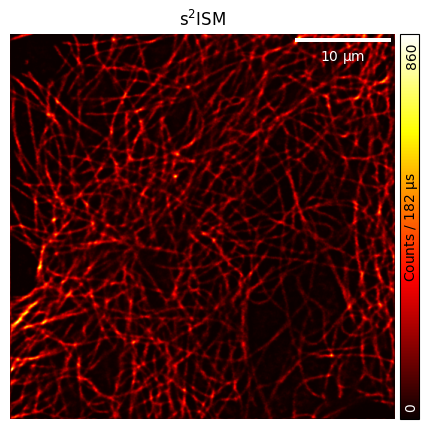

In [20]:
intensity_map = s2_flism.sum(-1)

fig, ax = plt.subplots(figsize = (15,5))

gra.ShowImg(intensity_map, pixel_size_x_um, pxdwelltime, fig = fig, ax = ax)
ax.set_title(r's$^2$ISM')



### Temporal Trace Comparison

This cell compares the decay profile of the central SPAD channel (channel 12) before and after reconstruction.  
The IRF and the raw data are shown alongside the s²ISM output to verify that:
- The reconstructed trace is not broader than the raw data (no artefact introduction).
- The peak position and decay shape are consistent with expectations.

> The variable `ch` selects the SPAD channel to inspect. Channel 12 is the central pixel of the 5×5 array and typically has the highest signal.


Text(0.5, 1.0, 'IRF — Raw — s²ISM reconstructed: temporal profile comparison')

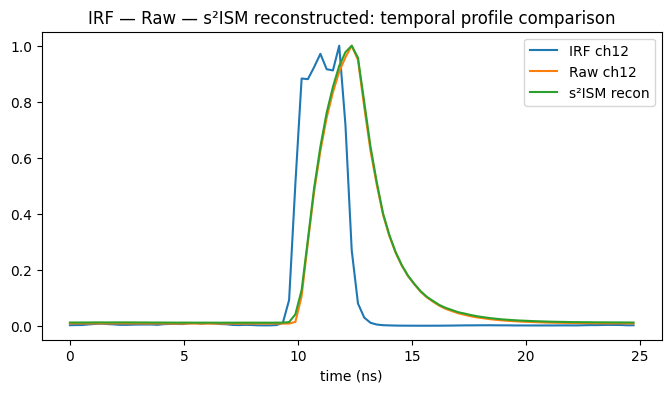

In [21]:
ch = 12  # SPAD channel to inspect

irf_ch    = irf_common_delay_realigned[:, ch]
raw_ch    = dset[:, :, :, ch].sum(axis=(0, 1))       # sum over x and y pixels
recon_ch  = s2_flism.sum(axis=(0, 1))                # s2_flism has no channel axis
recon_ch_no_IRF = s2_flism_no_IRF.sum(axis=(0, 1))   # s2_flism_no_IRF has no channel axis

# Normalise to peak for shape comparison
def norm(x): return x / x.max()

plt.figure(figsize=(8, 4))
plt.plot(time, norm(irf_ch),   label='IRF ch12')
# plt.plot(time, irf_from_fit[:,12], label='IRF from fit')
plt.plot(time, norm(raw_ch),   label='Raw ch12')
plt.plot(time, norm(recon_ch_no_IRF), label='s²ISM recon')
plt.xlabel('time (ns)')
plt.legend()
plt.title('IRF — Raw — s²ISM reconstructed: temporal profile comparison')


# Phasor Analysis

The **phasor approach** provides a model-free, graphical representation of fluorescence lifetime data.  
For each pixel, the decay trace is Fourier-transformed at the fundamental laser frequency ω = 2π·f_laser, and the result is represented as a complex number (phasor) in the unit-circle plane.

### Phase correction strategy

The s²ISM reconstruction introduces a systematic phase offset in the phasor domain that depends on which kernel was used:

| Kernel | Effect on phasor | Required correction |
|---|---|---|
| `psf_delta` | Spatial PSF removed; IRF broadening remains | Divide by the measured reference phasor normalised by the theoretical reference phasor |
| `psf_irf` | Both spatial PSF and IRF removed | The IRF deconvolution shifts all phasors by **π** (180°) — multiply by `exp(−iπ) = −1` |

**Why does `psf_irf` introduce a π phase shift?**  
Richardson-Lucy deconvolution treats the kernel as periodic (circular convolution). The measured IRF peak is not positioned at time bin 0 — it sits at some bin offset t₀ that corresponds to the physical arrival time of the laser pulse. When the IRF is divided out in frequency space, this offset translates to a linear phase `exp(−i·ω·t₀)`. For typical TCSPC settings, t₀ is close to half the laser period, so the resulting phase is approximately π.  
The correction `× exp(−iπ)` (i.e. sign flip) restores the phasors to their expected positions on the universal semicircle.

**Select the appropriate cell below** based on which reconstruction you are using.


In [22]:
# Compute phasors of the IRF and reference traces (used for correction)
irf_phasor      = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)
ref_phasor      = flim.calculate_phasor(ref_summed, threshold=0, harmonic=1)

# Select which reconstruction to analyse:
# - s2_flism_no_IRF: use with psf_delta → apply reference-dye correction below
# - s2_flism:        use with psf_irf   → apply π phase correction below
dato = s2_flism_no_IRF  # <-- change to s2_flism if you used the psf_irf kernel

s2_phasor_pix = flim.calculate_phasor(dato, harmonic=1)  # per-pixel phasors, shape: (y, x)
intensity_map = dato.sum(axis=-1)                         # integrated intensity map

### Phasor correction — Case A: `psf_delta` kernel (spatial deconvolution only)

Use this cell when the reconstruction was performed with `psf_delta`.  
The IRF is still present in the data, so we correct for it using the **measured reference-dye phasor**.

The correction divides each pixel phasor by the ratio `(measured ref phasor) / (theoretical ref phasor)`.  
This ratio encodes the full system response (IRF + any other instrumental phase shift) and removes it from the data.

The theoretical phasor of a mono-exponential dye with lifetime τ_ref at frequency ω is:
```
G_theory + i·S_theory = 1 / (1 − i·ω·τ_ref)
```


In [23]:
# ── Correction for psf_delta reconstruction ──────────────────────────────────
# Theoretical phasor of the monoexponential reference dye
omega = 2 * np.pi * laser_freq_mhz * 1e6          # angular frequency [rad/s]
tau_ref_s = tau_ref_for_phasor_ns * 1e-9                         # reference lifetime [s]
ref_phasor_theoretical = 1.0 / (1.0 - 1j * omega * tau_ref_s)

# System response = measured ref phasor / theoretical ref phasor
correction = ref_phasor / ref_phasor_theoretical
# Apply correction: divide every pixel phasor by the system response
phasor_map_corrected  = s2_phasor_pix / correction

### Phasor correction — Case B: `psf_irf` kernel (full spatio-temporal deconvolution)

Use this cell when the reconstruction was performed with `psf_irf` or `psf_irf_smoothed`.  
In this case the IRF has already been deconvolved, but the deconvolution introduces a phase shift of **π** because the IRF peak is not located at time bin 0 (it sits roughly at the centre of the time axis).  
The correction simply multiplies all phasors by `exp(−iπ) = −1`, rotating them by 180° back onto the correct semicircle.


In [24]:
# ── Correction for psf_irf reconstruction ────────────────────────────────────
#phasor_map_corrected  = phasor_map * np.exp(1j * -np.pi)

## Lifetime Maps and Thresholding

From the corrected per-pixel phasors we derive two complementary lifetime estimators:

- **τ_m (modulation lifetime)** – derived from the modulus of the phasor: `τ_m = √(1/|p|² − 1) / ω`. Sensitive to the width of the lifetime distribution.
- **τ_φ (phase lifetime)** – derived from the phase angle: `τ_φ = tan(φ) / ω`. Sensitive to the mean lifetime.

For a **pure mono-exponential** emitter, τ_m = τ_φ. A difference between the two is a signature of **multi-exponential** decay or FRET.

A threshold on the intensity map is applied to exclude background pixels (below `threshold` × max intensity).


In [25]:
tau_m_map   = flim.calculate_tau_m(phasor_map_corrected,   dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map = flim.calculate_tau_phi(phasor_map_corrected, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map # choose tau_m as the primary lifetime estimator

# Threshold: pixels with intensity below (threshold × max intensity) are excluded
threshold = 0.05
thresholded_phasor_map    = flim.threshold_phasor(intensity_map, phasor_map_corrected, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map, intensity=intensity_map, threshold=threshold,
)

print(f"\nValid pixels after threshold: {np.sum(lifetime_mask)}")



Valid pixels after threshold: 172881


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


### Phasor Plot

Text(0.5, 1.0, 'Phasor — s$^2$ISM (corrected)')

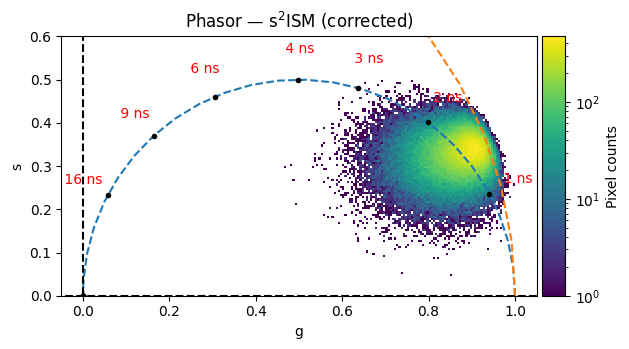

In [26]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title(r"Phasor — s$^2$ISM (corrected)")



### τ_m vs τ_φ Comparison

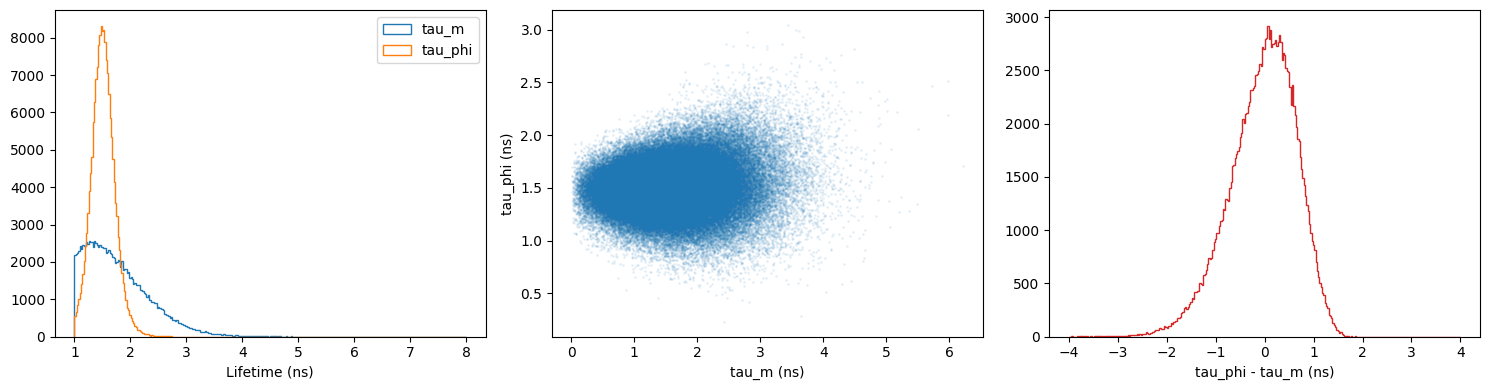

In [27]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare   = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(tau_m_compare,   bins=300, range=(1, 8), histtype="step", label="tau_m")
axs[0].hist(tau_phi_compare, bins=300, range=(1, 8), histtype="step", label="tau_phi")
axs[0].set_xlabel("Lifetime (ns)")
axs[0].legend()
axs[1].scatter(tau_m_compare, tau_phi_compare, s=1, alpha=0.08)
axs[1].set_xlabel("tau_m (ns)")
axs[1].set_ylabel("tau_phi (ns)")
axs[2].hist(tau_diff_compare, bins=300, range=(-4, 4), histtype="step", color="tab:red")
axs[2].set_xlabel("tau_phi - tau_m (ns)")
fig.tight_layout()



### Lifetime Summary Figure

`graph.plot_lifetime_summary` produces a multi-panel overview combining:
- Intensity image
- Lifetime map (colour-coded by τ_m)
- Weighted histogram of lifetime values

**Parameters to adjust:**
- `lifetime_bounds` – Colour scale limits for the lifetime map [ns]. Adjust based on your sample's expected lifetime range.
- `crop` – Number of pixels to crop from each edge (removes border artefacts from the reconstruction).
- `threshold` – Same threshold fraction as above.
- `colormap` – Colourmap for the lifetime image (`"turbo"`, `"jet"`, `"magma"`, etc.).
- `weighted_histogram` – If `True`, each pixel contributes to the histogram weighted by its intensity.


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)
/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

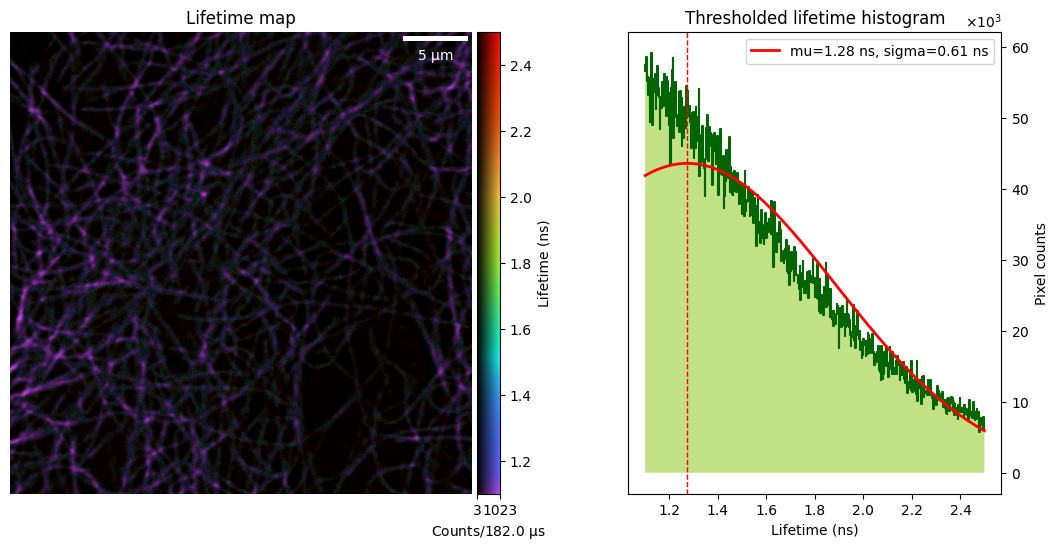

In [28]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.1, 2.5], # <-- adjust to your sample's expected lifetime range [ns]
    crop=30,                      # pixels to crop from each border
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)



In [32]:
if EXPORT_PATH is not None:
    common_attrs = {
        "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz,
        "laser_period_ns": laser_period_ns,
    }
    target_path, output_run_id = write_h5_output_run(
        FILE_WITH_CALIBRATION,
        "s2ism",
        [
            H5OutputProduct("decay", s2_flism, attrs={**common_attrs, "data_role": "s2ism_full_deconvolution_decay", "axis_order": "y,x,time_bin"}),
            H5OutputProduct("decay_no_irf", s2_flism_no_IRF, attrs={**common_attrs, "data_role": "s2ism_spatial_deconvolution_decay", "axis_order": "y,x,time_bin"}),
            H5OutputProduct("selected_decay", dato, attrs={**common_attrs, "data_role": "s2ism_selected_decay_for_phasor", "axis_order": "y,x,time_bin"}),
            H5OutputProduct("intensity", intensity_map, attrs={**common_attrs, "data_role": "s2ism_integrated_intensity", "axis_order": "y,x"}),
        ],
        mode="copy",
        output_path=EXPORT_PATH,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="s2ISM reconstruction",
        algorithm_name="s2.batch_reconstruction",
        parameters={
            "full_kernel": "psf_irf",
            "spatial_kernel": "psf_delta",
            "full_max_iter": 7,
            "spatial_max_iter": 5,
            "batch_size": [301, 301],
            "overlap": 40,
            "selected_product": "decay_no_irf" if dato is s2_flism_no_IRF else "decay",
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": dato.shape[0],
            "output_nx": dato.shape[1],
            "output_time_bins": dato.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "s2ism",
        },
        axes=[H5OutputProduct("time_ns", np.arange(nbin, dtype=float) * laser_period_ns / nbin, attrs={"axis": "time", "units": "ns"})],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x,time_bin",
            "output_data_path": "/output/{run_id}/products/selected_decay",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (EXPORT_PATH = None).")


if EXPORT_PATH is not None:
    phasor_source_path = PIPELINE_H5 if "PIPELINE_H5" in globals() else FILE_WITH_CALIBRATION
    phasor_mode = "append" if Path(phasor_source_path) == Path(EXPORT_PATH) else "copy"
    phasor_output_path = None if phasor_mode == "append" else EXPORT_PATH
    common_attrs = {
        "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz if "laser_freq_mhz" in globals() else laser_frequency_mhz,
        "laser_period_ns": laser_period_ns,
    }
    products = [
        H5OutputProduct("intensity", intensity_map, attrs={**common_attrs, "data_role": "integrated_intensity", "axis_order": "y,x"}),
        H5OutputProduct("phasor_real", np.real(phasor_map_corrected), attrs={**common_attrs, "data_role": "phasor_real", "axis_order": "y,x"}),
        H5OutputProduct("phasor_imag", np.imag(phasor_map_corrected), attrs={**common_attrs, "data_role": "phasor_imag", "axis_order": "y,x"}),
        H5OutputProduct("tau_m_ns", tau_m_map, attrs={**common_attrs, "data_role": "tau_m", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("tau_phi_ns", tau_phi_map, attrs={**common_attrs, "data_role": "tau_phi", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("tau_ns", lifetime_map, attrs={**common_attrs, "data_role": "primary_lifetime", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("decay", dato, attrs={**common_attrs, "data_role": "s2ism_selected_decay_for_phasor", "axis_order": "y,x,time_bin"}),
        H5OutputProduct("irf", irf_summed, attrs={**common_attrs, "data_role": "channel_summed_irf", "axis_order": "time_bin"}),
        H5OutputProduct("ref", ref_summed, attrs={**common_attrs, "data_role": "channel_summed_reference", "axis_order": "time_bin"}),
        H5OutputProduct("irf_phasor_real", np.asarray(np.real(irf_phasor)), attrs={**common_attrs, "data_role": "irf_phasor_real"}),
        H5OutputProduct("irf_phasor_imag", np.asarray(np.imag(irf_phasor)), attrs={**common_attrs, "data_role": "irf_phasor_imag"}),
        H5OutputProduct("ref_phasor_real", np.asarray(np.real(ref_phasor)), attrs={**common_attrs, "data_role": "ref_phasor_real"}),
        H5OutputProduct("ref_phasor_imag", np.asarray(np.imag(ref_phasor)), attrs={**common_attrs, "data_role": "ref_phasor_imag"}),
        H5OutputProduct("corr_real", np.asarray(np.real(correction)), attrs={**common_attrs, "data_role": "phasor_correction_real"}),
        H5OutputProduct("corr_imag", np.asarray(np.imag(correction)), attrs={**common_attrs, "data_role": "phasor_correction_imag"}),
    ]
    target_path, output_run_id = write_h5_output_run(
        phasor_source_path,
        "s2_phasor",
        products,
        mode=phasor_mode,
        output_path=phasor_output_path,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="Phasor lifetime",
        algorithm_name="phasor_correction",
        parameters={
            "reference_type": REFERENCE_TYPE,
            "tau_ref_input_ns": TAU_REF,
            "tau_ref_used_ns": tau_ref_for_phasor_ns,
            "threshold_fraction": threshold,
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": intensity_map.shape[0],
            "output_nx": intensity_map.shape[1],
            "output_time_bins": dato.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "s2ism",
        },
        axes=[H5OutputProduct("time_ns", np.arange(nbin, dtype=float) * laser_period_ns / nbin, attrs={"axis": "time", "units": "ns"})],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x",
            "output_data_path": "/output/{run_id}/products/tau_ns",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (EXPORT_PATH = None).")


Saved s2ism -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_s2ism_with_phasor.h5


In [34]:
show_h5_structure_html(EXPORT_PATH if EXPORT_PATH is not None else FILE_WITH_CALIBRATION)

'<script>\n(function () {\n  // Expand / collapse ALL groups in the widget\n  function h5All(widgetId, open) {\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'details.h5-branch\').forEach(function(d) {\n      d.open = open;\n    });\n  }\n\n  // Expand / collapse all groups at a specific depth inside a widget\n  function h5LevelToggle(widgetId, depth, open, btn) {\n    // Stop the click from toggling the parent <details>\n    if (btn) { btn.closest(\'details\') && (event || window.event) && (event || window.event).stopPropagation(); }\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'li.h5-li-group[data-depth="\' + depth + \'"]\').forEach(function(li) {\n      var det = li.querySelector(\':scope > details.h5-branch\');\n      if (det) det.open = open;\n    });\n  }\n\n  // Expose globally so onclick= attributes work\n  window.h5All = h5All;\n  window.h5LevelToggle = h5LevelTogg